# ETF Fragility Through Market Cycles

Motivating figure for the paper: how does the `vol_12w` fragility signal evolve for representative fixed-income ETFs through key stress episodes (COVID 2020, rate hike cycle 2022)?

Representative ETFs span the fragility spectrum:
- **TLT** — iShares 20+ Year Treasury (long duration, high rate sensitivity)
- **HYG** — iShares High Yield Corporate Bond (credit risk)
- **LQD** — iShares IG Corporate Bond (investment grade)
- **BND** — Vanguard Total Bond Market (broad aggregate)
- **EMB** — iShares EM USD Bond (emerging markets)
- **AGG** — iShares Core US Aggregate (benchmark)

In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd().resolve()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

from src import config
from src.features.rolling_risk import add_rolling_risk_metrics
from src.features.stress_index import add_stress_index

plt.rcParams.update({
    'figure.dpi': 130,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 9,
})

PANEL_MODE = 'offline'  # switch to 'live' after running the live pipeline

panel = pd.read_csv(config.core_panel_csv(PANEL_MODE), parse_dates=['Date', 'Inception'])
panel = panel.sort_values(['Symbol', 'Date']).reset_index(drop=True)

if 'vol_12w' not in panel.columns:
    panel = add_rolling_risk_metrics(panel)
if 'stress_index' not in panel.columns:
    panel = add_stress_index(panel)

print(f'Panel mode: {PANEL_MODE}  |  path: {config.core_panel_csv(PANEL_MODE)}')
print(f'Panel: {len(panel):,} rows  |  {panel.Symbol.nunique()} ETFs  |  '
      f'{panel.Date.min().date()} to {panel.Date.max().date()}')

ETFS = ['TLT', 'HYG', 'LQD', 'BND', 'EMB', 'AGG']
available = [t for t in ETFS if t in panel['Symbol'].values]
missing   = [t for t in ETFS if t not in panel['Symbol'].values]
print(f'Representative ETFs found: {available}')
if missing:
    print(f'Not in universe: {missing}')

COLORS = {
    'TLT': '#1f77b4',   # blue   — long Treasury
    'HYG': '#d62728',   # red    — high yield
    'LQD': '#ff7f0e',   # orange — IG corp
    'BND': '#2ca02c',   # green  — total market
    'EMB': '#9467bd',   # purple — EM
    'AGG': '#8c564b',   # brown  — aggregate
}

Panel mode: offline  |  path: data/processed/offline/core_panel.csv
Panel: 157,171 rows  |  348 ETFs  |  2016-05-13 to 2026-04-24
Representative ETFs found: ['TLT', 'HYG', 'LQD', 'BND', 'EMB', 'AGG']


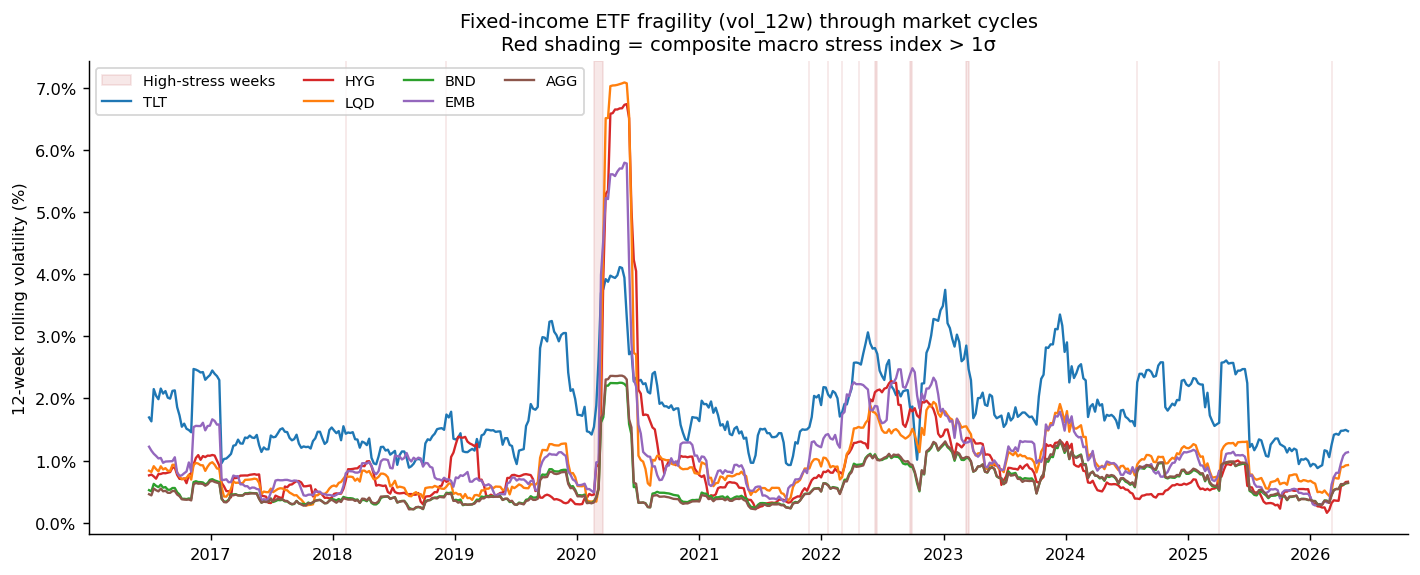

vol_12w summary by ETF:


,Mean,Std,P10,P90,Max
Symbol,,,,,
TLT,0.01847,0.00664,0.01148,0.02810,0.04116
HYG,0.00937,0.00972,0.00370,0.01527,0.06740
LQD,0.01040,0.00982,0.00482,0.01531,0.07088
BND,0.00625,0.00357,0.00316,0.01041,0.02254
EMB,0.01107,0.00831,0.00485,0.01815,0.05796
AGG,0.00622,0.00375,0.00312,0.01051,0.02368


In [2]:
# ── Fragility time series — vol_12w for representative ETFs ───────────────
rep = panel[panel['Symbol'].isin(available)].dropna(subset=['vol_12w']).copy()

stress_ts = (panel[['Date', 'high_stress']]
             .drop_duplicates('Date').set_index('Date').sort_index())

fig, ax = plt.subplots(figsize=(11, 4.5))

# Stress shading
ax.fill_between(stress_ts.index, 0, 1,
                where=stress_ts['high_stress'] == 1,
                transform=ax.get_xaxis_transform(),
                alpha=0.10, color='firebrick', label='High-stress weeks')

for sym in available:
    s = rep[rep['Symbol'] == sym].set_index('Date')['vol_12w']
    ax.plot(s.index, s * 100, label=sym, color=COLORS.get(sym), lw=1.3)

ax.set_ylabel('12-week rolling volatility (%)')
ax.set_title('Fixed-income ETF fragility (vol_12w) through market cycles\n'
             'Red shading = composite macro stress index > 1σ')
ax.legend(ncol=4, fontsize=8, loc='upper left')
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f%%'))
plt.tight_layout()
plt.show()

# Summary stats per ETF
summary = (rep.groupby('Symbol')['vol_12w']
           .agg(mean='mean', std='std',
                p10=lambda x: x.quantile(0.1),
                p90=lambda x: x.quantile(0.9),
                max='max')
           .loc[available]
           .round(5))
summary.columns = ['Mean', 'Std', 'P10', 'P90', 'Max']
print('vol_12w summary by ETF:')
display(summary)

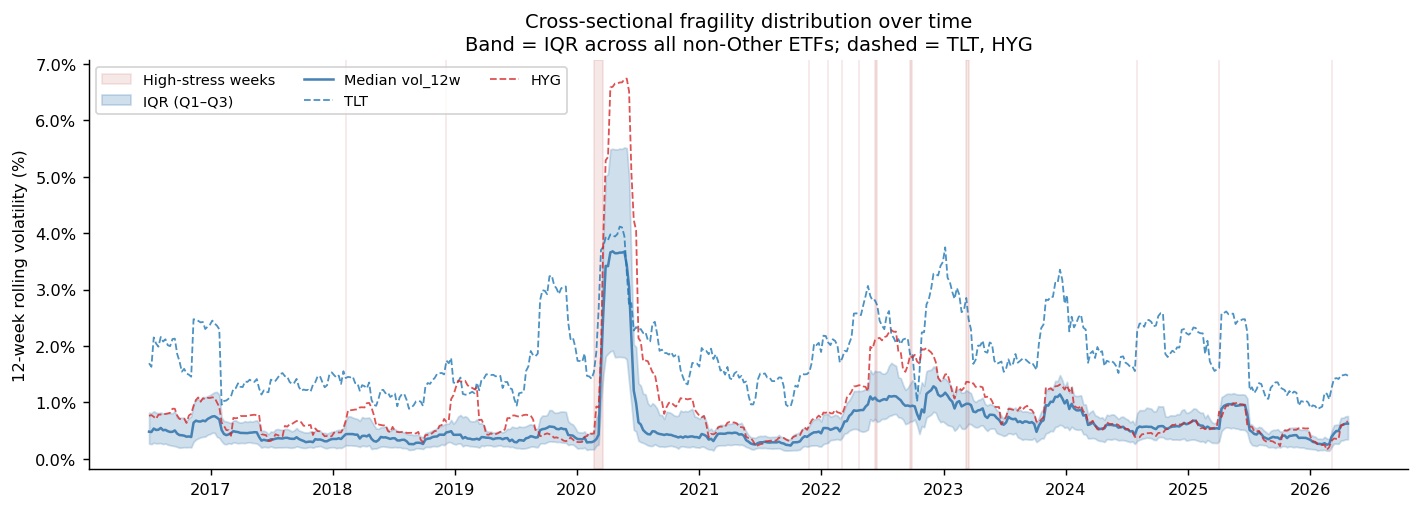

In [3]:
# ── Cross-sectional fragility distribution over time ───────────────────────
# Median + IQR band across all ETFs: shows how the typical fragility level
# and its dispersion shift through market regimes.

univ = panel[panel['category_bucket'] != 'Other'].dropna(subset=['vol_12w'])

weekly_pct = (univ.groupby('Date')['vol_12w']
              .quantile([0.25, 0.50, 0.75])
              .unstack()
              .rename(columns={0.25: 'q25', 0.50: 'med', 0.75: 'q75'})
              .sort_index())

fig, ax = plt.subplots(figsize=(11, 4))

ax.fill_between(weekly_pct.index, 0, 1,
                where=stress_ts.reindex(weekly_pct.index)['high_stress'] == 1,
                transform=ax.get_xaxis_transform(),
                alpha=0.10, color='firebrick', label='High-stress weeks')

ax.fill_between(weekly_pct.index,
                weekly_pct['q25'] * 100, weekly_pct['q75'] * 100,
                alpha=0.25, color='steelblue', label='IQR (Q1–Q3)')
ax.plot(weekly_pct.index, weekly_pct['med'] * 100,
        color='steelblue', lw=1.4, label='Median vol_12w')

# Overlay representative ETFs
for sym in ['TLT', 'HYG']:
    if sym in available:
        s = rep[rep['Symbol'] == sym].set_index('Date')['vol_12w']
        ax.plot(s.index, s * 100, color=COLORS[sym], lw=1.0,
                ls='--', label=sym, alpha=0.8)

ax.set_ylabel('12-week rolling volatility (%)')
ax.set_title('Cross-sectional fragility distribution over time\n'
             'Band = IQR across all non-Other ETFs; dashed = TLT, HYG')
ax.legend(ncol=3, fontsize=8)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f%%'))
plt.tight_layout()
plt.show()

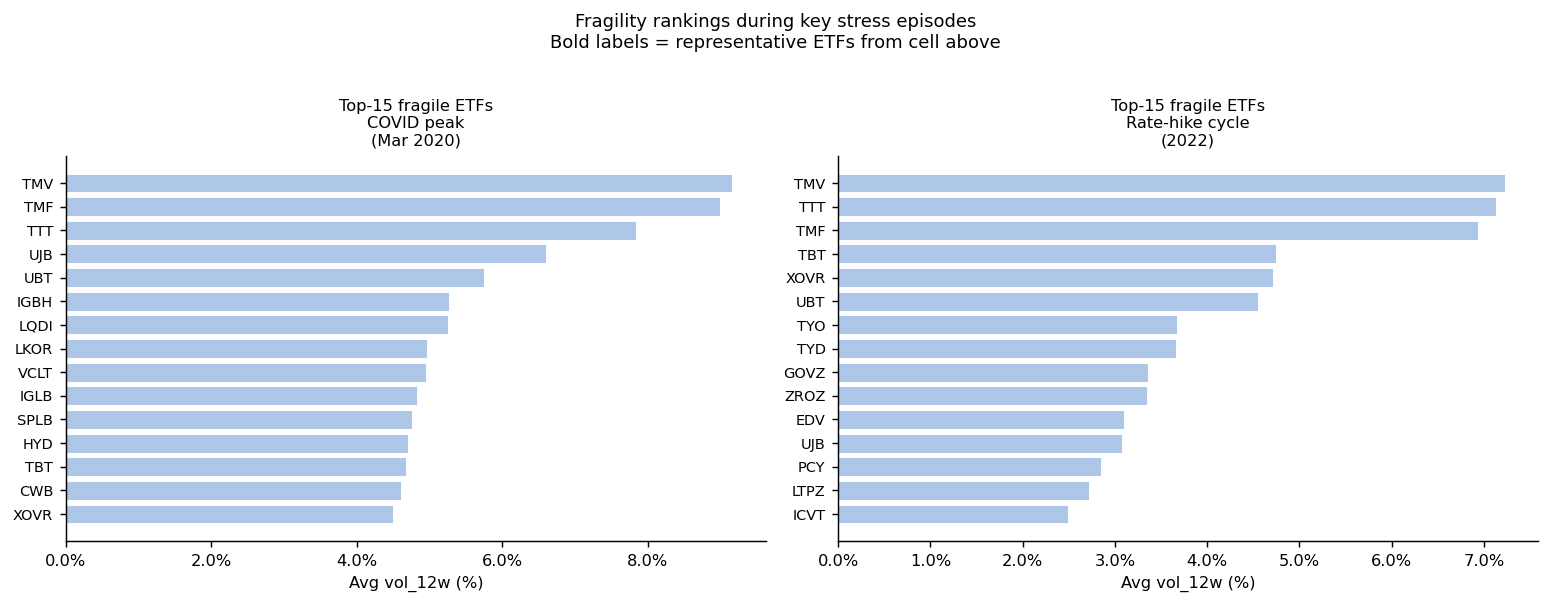


Representative ETF percentile rank during each episode (lower = more fragile):
  COVID peak (Mar 2020): TLT: 24th pct  |  HYG: 18th pct  |  LQD: 11th pct  |  BND: 70th pct  |  EMB: 18th pct  |  AGG: 69th pct
  Rate-hike cycle (2022): TLT: 6th pct  |  HYG: 17th pct  |  LQD: 23th pct  |  BND: 53th pct  |  EMB: 9th pct  |  AGG: 53th pct


In [4]:
# ── Fragility rankings during key stress episodes ─────────────────────────
# Snapshot vol_12w around COVID peak (Mar 2020) and rate-hike peak (Oct 2022)
# to show which ETF types were most fragile during each episode.

EPISODES = {
    'COVID peak\n(Mar 2020)':     ('2020-02-01', '2020-04-30'),
    'Rate-hike cycle\n(2022)':    ('2022-01-01', '2022-12-31'),
}

ep_rows = []
for label, (start, end) in EPISODES.items():
    window = panel[(panel['Date'] >= start) & (panel['Date'] <= end)]
    if window.empty:
        continue
    avg = (window.groupby('Symbol')['vol_12w'].mean()
           .dropna()
           .sort_values(ascending=False))
    ep_rows.append({'episode': label, 'ranking': avg})

if not ep_rows:
    print('No data for the specified stress episodes — check panel date range.')
else:
    n_ep = len(ep_rows)
    fig, axes = plt.subplots(1, n_ep, figsize=(6 * n_ep, 4.5), sharey=False)
    if n_ep == 1:
        axes = [axes]

    for ax, row in zip(axes, ep_rows):
        top = row['ranking'].head(15)
        colors = [COLORS.get(s, '#aec7e8') for s in top.index]
        bars = ax.barh(range(len(top)), top.values * 100,
                       color=colors, edgecolor='white', linewidth=0.5)
        ax.set_yticks(range(len(top)))
        ax.set_yticklabels(top.index, fontsize=8)
        ax.invert_yaxis()
        ax.set_xlabel('Avg vol_12w (%)')
        ax.set_title(f'Top-15 fragile ETFs\n{row["episode"]}', fontsize=9)
        ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f%%'))

        # Highlight representative ETFs
        for i, sym in enumerate(top.index):
            if sym in COLORS:
                ax.get_yticklabels()[i].set_fontweight('bold')

    plt.suptitle('Fragility rankings during key stress episodes\n'
                 'Bold labels = representative ETFs from cell above', fontsize=10, y=1.02)
    plt.tight_layout()
    plt.show()

    # Print the rep-ETF ranks within each episode
    print('\nRepresentative ETF percentile rank during each episode (lower = more fragile):')
    for row in ep_rows:
        n = len(row['ranking'])
        ranks = {s: round(100 * (row['ranking'].index.get_loc(s) + 1) / n, 1)
                 for s in available if s in row['ranking'].index}
        ep_label = row['episode'].replace('\n', ' ')
        print(f"  {ep_label}: " + '  |  '.join(f"{s}: {r:.0f}th pct" for s, r in ranks.items()))

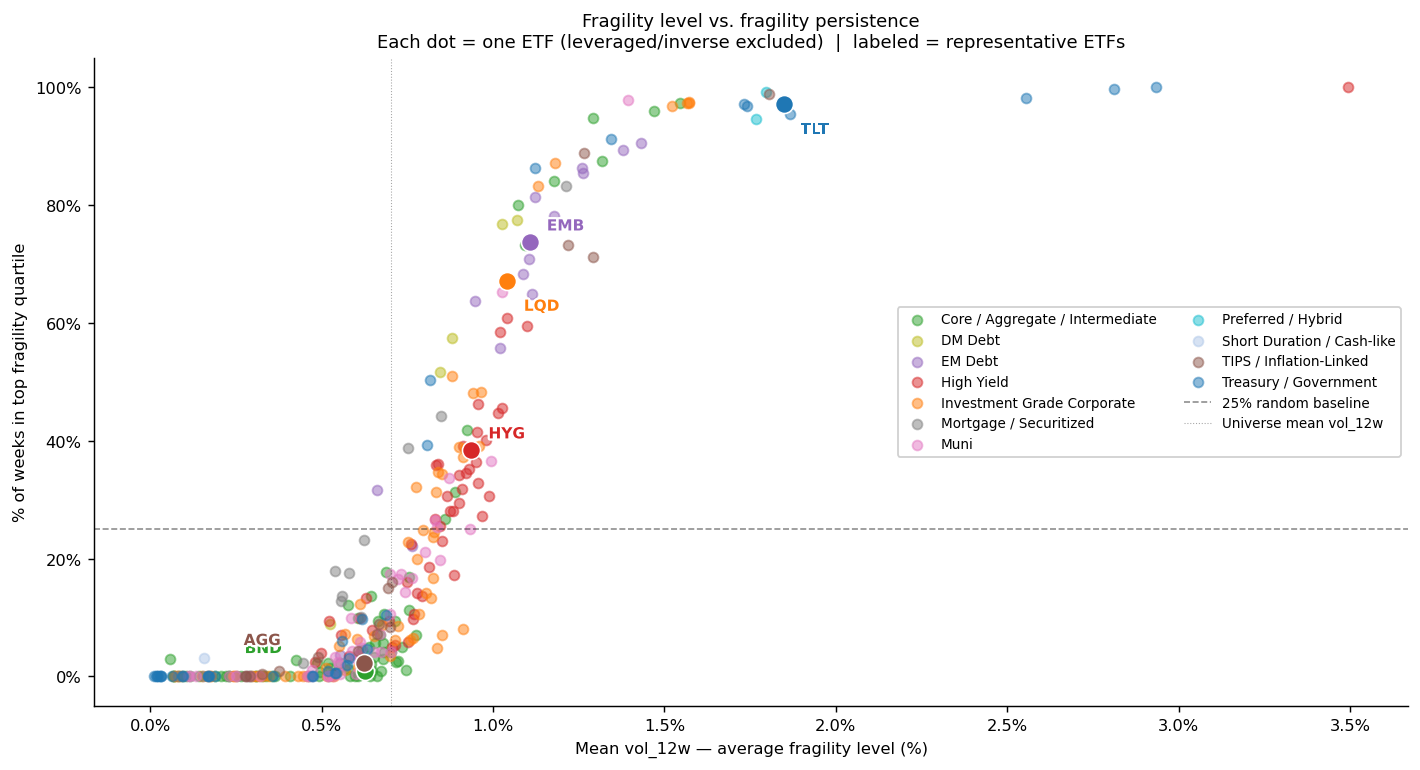

Representative ETFs — fragility level vs. persistence:


,Category,Mean vol_12w (%),% wks top-Q,N weeks,Univ. rank
Symbol,,,,,
TLT,Treasury / Government,1.85,97.1,513,12
HYG,High Yield,0.94,38.4,513,71
LQD,Investment Grade Corporate,1.04,67.1,513,44
BND,Core / Aggregate / Intermediate,0.63,1.0,513,232
EMB,EM Debt,1.11,73.7,513,38
AGG,Core / Aggregate / Intermediate,0.62,2.3,513,216


In [5]:
# ── Scatter: fragility level vs. persistence (% time in top quartile) ─────
# Each dot = one ETF (Other/leveraged excluded).
# X = mean vol_12w (how fragile on average)
# Y = % weeks in cross-sectional top quartile (how persistently fragile)
# Color = category bucket  |  Labeled = representative ETFs

import matplotlib.patheffects as pe

weekly_q75 = (panel.dropna(subset=['vol_12w'])
              .groupby('Date')['vol_12w']
              .quantile(0.75)
              .rename('q75'))

frag = (panel.dropna(subset=['vol_12w'])
        .join(weekly_q75, on='Date')
        .assign(top_q=lambda d: (d['vol_12w'] >= d['q75']).astype(int)))

etf_stats = (frag[frag['category_bucket'] != 'Other']
             .groupby(['Symbol', 'category_bucket'])
             .agg(mean_vol=('vol_12w', 'mean'),
                  pct_top_q=('top_q', 'mean'),
                  n_weeks=('top_q', 'count'))
             .query('n_weeks >= 52')
             .reset_index())

CAT_COLORS = {
    'Treasury / Government':           '#1f77b4',
    'Investment Grade Corporate':      '#ff7f0e',
    'High Yield':                      '#d62728',
    'Core / Aggregate / Intermediate': '#2ca02c',
    'EM Debt':                         '#9467bd',
    'TIPS / Inflation-Linked':         '#8c564b',
    'Muni':                            '#e377c2',
    'Mortgage / Securitized':          '#7f7f7f',
    'DM Debt':                         '#bcbd22',
    'Preferred / Hybrid':              '#17becf',
    'Short Duration / Cash-like':      '#aec7e8',
}

fig, ax = plt.subplots(figsize=(11, 6))

for cat, grp in etf_stats.groupby('category_bucket'):
    color = CAT_COLORS.get(cat, '#aaaaaa')
    ax.scatter(grp['mean_vol'] * 100, grp['pct_top_q'] * 100,
               color=color, alpha=0.50, s=30, label=cat, zorder=2)

# Labeled representative ETFs
label_offsets = {
    'TLT': ( 0.05, -5), 'HYG': ( 0.05,  2),
    'LQD': ( 0.05, -5), 'BND': (-0.35,  3),
    'EMB': ( 0.05,  2), 'AGG': (-0.35,  3),
}
for sym in available:
    row = etf_stats[etf_stats['Symbol'] == sym]
    if row.empty:
        continue
    x = float(row['mean_vol'].iloc[0]) * 100
    y = float(row['pct_top_q'].iloc[0]) * 100
    color = COLORS.get(sym, '#333333')
    ax.scatter(x, y, color=color, s=100, zorder=5,
               edgecolors='white', linewidths=0.9)
    dx, dy = label_offsets.get(sym, (0.05, 2))
    ax.annotate(sym, (x, y), xytext=(x + dx, y + dy),
                fontsize=8.5, fontweight='bold', color=color,
                path_effects=[pe.withStroke(linewidth=2.5, foreground='white')])

ax.axhline(25, color='black', lw=0.9, ls='--', alpha=0.45, label='25% random baseline')
ax.axvline(etf_stats['mean_vol'].mean() * 100, color='black', lw=0.6,
           ls=':', alpha=0.35, label='Universe mean vol_12w')

ax.set_xlabel('Mean vol_12w — average fragility level (%)', fontsize=9)
ax.set_ylabel('% of weeks in top fragility quartile', fontsize=9)
ax.set_title(
    'Fragility level vs. fragility persistence\n'
    'Each dot = one ETF (leveraged/inverse excluded)  |  labeled = representative ETFs',
    fontsize=10)
ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f%%'))
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))

handles, labels_leg = ax.get_legend_handles_labels()
ax.legend(handles, labels_leg, fontsize=7.5, ncol=2,
          loc='center right', framealpha=0.9, edgecolor='#cccccc')

plt.tight_layout()
plt.show()

# Representative ETF summary table
if available:
    rep_rows = etf_stats[etf_stats['Symbol'].isin(available)].set_index('Symbol')
    rep_rows = rep_rows.loc[[s for s in available if s in rep_rows.index]]
    rep_rows = rep_rows.copy()
    rep_rows['Mean vol_12w (%)'] = (rep_rows['mean_vol'] * 100).round(2)
    rep_rows['% wks top-Q']     = (rep_rows['pct_top_q'] * 100).round(1)
    univ_ranks = (etf_stats.set_index('Symbol')['pct_top_q']
                  .rank(ascending=False, method='min').astype(int))
    rep_rows['Univ. rank'] = univ_ranks.reindex(rep_rows.index)
    print('Representative ETFs — fragility level vs. persistence:')
    display(rep_rows[['category_bucket', 'Mean vol_12w (%)', '% wks top-Q',
                       'n_weeks', 'Univ. rank']]
            .rename(columns={'category_bucket': 'Category', 'n_weeks': 'N weeks'}))